In [3]:
import pandas as pd
import os
import duckdb
import numpy as np
import matplotlib.pyplot as plt

In [10]:
path = "datasets\en.openfoodfacts.org.products.csv"

In [ ]:
fichier_csv = 'datasets/en.openfoodfacts.org.products.csv'

# On ajoute "parallel=false" à la fin des paramètres
parametres_csv = f"'{fichier_csv}', sep='\t', quote='\"', ignore_errors=true, null_padding=true, parallel=false"

# 1. Requête pour nutriscore_score
print("Distribution de nutriscore_score:")
requete_score = f"""
    SELECT nutriscore_score, COUNT(*) AS count
    FROM read_csv_auto({parametres_csv})
    GROUP BY nutriscore_score
    ORDER BY count DESC
"""
print(duckdb.query(requete_score).df())

# 2. Requête pour nutriscore_grade
print("\nDistribution de nutriscore_grade:")
requete_grade = f"""
    SELECT nutriscore_grade, COUNT(*) AS count
    FROM read_csv_auto({parametres_csv})
    GROUP BY nutriscore_grade
    ORDER BY count DESC
"""
print(duckdb.query(requete_grade).df())

Distribution de nutriscore_score:
    nutriscore_score    count
0               <NA>  3071928
1                  0    88361
2                  4    56678
3                  3    51713
4                 19    51381
..               ...      ...
70                49       66
71                54       46
72                53       31
73                52       22
74               -18        2

[75 rows x 2 columns]

Distribution de nutriscore_grade:
  nutriscore_grade    count
0          unknown  2905161
1                e   380809
2                d   341272
3                c   280729
4                a   196268
5                b   157367
6   not-applicable    98142
7              NaN    68625


On remarque que la plupart des valeur de nutriscore score sont manquante , et que la majeure partie des valeurs de nutriscore grade sont 'unknown' qui corresponds a une valeur manquante  

In [4]:
colonnes_a_garder = [
    # Cibles et identification (à ajouter depuis le dataset principal)
    "code", "product_name", "main_category", "nutriscore_grade", "nutriscore_score",
    
    # Points négatifs du Nutri-Score
    "energy_100g", 
    "sugars_100g", 
    "saturated-fat_100g", 
    "sodium_100g", 
    
    # Points positifs du Nutri-Score
    "proteins_100g", 
    "fiber_100g", 
    "fruits-vegetables-legumes_100g",
    
    # Variables globales utiles au modèle
    "fat_100g",
    "carbohydrates_100g"
]



fichier_source = 'datasets/en.openfoodfacts.org.products.csv'
fichier_out = 'datasets/nutriscore_donnees_propres.csv'


taille_palier = 50000  # Nombre de lignes traitées à chaque cycle (très léger pour la RAM)

# Sécurité : on supprime le fichier de sortie s'il existe déjà pour ne pas écrire en double
if os.path.exists(fichier_out):
    os.remove(fichier_out)

print("Début du traitement par paliers...")

# Lecture du gros fichier morceau par morceau
for i, chunk in enumerate(pd.read_csv(
    fichier_source, 
    sep='\t', 
    usecols=lambda c: c in colonnes_a_garder, # Ne charge en RAM que nos 12 colonnes
    chunksize=taille_palier,
    on_bad_lines='skip', # Saute les fameuses lignes corrompues
    dtype=str # Évite les erreurs de types mélangés en cours de route
)):
    
    # 1. On filtre le palier : on ne garde que les lignes où le nutriscore est présent
    # (On supprime la ligne si la lettre ET le score numérique sont manquants)
    chunk_filtre = chunk.dropna(subset=['nutriscore_grade', 'nutriscore_score'], how='all')

    # on retire les lignes avec des nutriscore_grade egual a 'unknown' ou 'not-applicable'
    chunk_filtre = chunk_filtre[~chunk_filtre['nutriscore_grade'].isin(['unknown', 'not-applicable','Italy', '590', '106'])]
    
    # 2. On écrit ce palier filtré dans le nouveau fichier
    if not chunk_filtre.empty:
        # mode='a' (append) ajoute les données à la suite du fichier
        # header=(i==0) écrit les noms des colonnes UNIQUEMENT lors du 1er palier   
        chunk_filtre.to_csv(fichier_out, mode='a', index=False, sep=';', header=(i==0))
    
    # Affichage de la progression pour vous rassurer !
    lignes_lues = taille_palier * (i + 1)
    print(f"Palier {i+1} terminé : ~ {lignes_lues} lignes analysées...")

print("\ntraitement terminé")

Début du traitement par paliers...
Palier 1 terminé : ~ 50000 lignes analysées...
Palier 2 terminé : ~ 100000 lignes analysées...
Palier 3 terminé : ~ 150000 lignes analysées...
Palier 4 terminé : ~ 200000 lignes analysées...
Palier 5 terminé : ~ 250000 lignes analysées...
Palier 6 terminé : ~ 300000 lignes analysées...
Palier 7 terminé : ~ 350000 lignes analysées...
Palier 8 terminé : ~ 400000 lignes analysées...
Palier 9 terminé : ~ 450000 lignes analysées...
Palier 10 terminé : ~ 500000 lignes analysées...
Palier 11 terminé : ~ 550000 lignes analysées...
Palier 12 terminé : ~ 600000 lignes analysées...
Palier 13 terminé : ~ 650000 lignes analysées...
Palier 14 terminé : ~ 700000 lignes analysées...
Palier 15 terminé : ~ 750000 lignes analysées...
Palier 16 terminé : ~ 800000 lignes analysées...
Palier 17 terminé : ~ 850000 lignes analysées...
Palier 18 terminé : ~ 900000 lignes analysées...
Palier 19 terminé : ~ 950000 lignes analysées...
Palier 20 terminé : ~ 1000000 lignes analysé

In [5]:
# verification du nouveau fichier (summary)


fichier_csv = fichier_out  
taille_morceau = 1000 

stats = {
    'valeurs_manquantes': {}, # <-- NOUVEAU : pour toutes les colonnes
    'count': {},              # Valeurs non nulles (colonnes numériques)
    'sum': {},
    'min': {},
    'max': {}
}

for chunk in pd.read_csv(fichier_csv, chunksize=taille_morceau, sep=';', encoding="utf-8" , on_bad_lines='skip'):
    
    # 1. On compte les valeurs manquantes pour TOUTES les colonnes
    for col in chunk.columns:
        if col not in stats['valeurs_manquantes']:
            stats['valeurs_manquantes'][col] = 0
            
        # .isna().sum() donne le nombre de NaN dans le morceau actuel
        stats['valeurs_manquantes'][col] += chunk[col].isna().sum()

    # 2. On calcule les stats descriptives uniquement pour les numériques
    colonnes_numeriques = chunk.select_dtypes(include=[np.number]).columns
    
    for col in colonnes_numeriques:
        if col not in stats['count']:
            stats['count'][col] = 0
            stats['sum'][col] = 0
            stats['min'][col] = np.inf
            stats['max'][col] = -np.inf
            
        col_data = chunk[col].dropna() 
        
        stats['count'][col] += col_data.count()
        stats['sum'][col] += col_data.sum()
        
        if not col_data.empty: # Sécurité si le chunk ne contient que des NaN pour cette colonne
            chunk_min = col_data.min()
            chunk_max = col_data.max()
            
            if chunk_min < stats['min'][col]:
                stats['min'][col] = chunk_min
            if chunk_max > stats['max'][col]:
                stats['max'][col] = chunk_max

# Construction du résultat final
resultats_finaux = {}
for col in chunk.columns:
    # On initialise avec les valeurs manquantes qui concernent tout le monde
    resultats_finaux[col] = {
        'Valeurs_Manquantes': stats['valeurs_manquantes'][col]
    }
    
    # Si la colonne est numérique, on ajoute le reste
    if col in stats['count']:
        count = stats['count'][col]
        mean = stats['sum'][col] / count if count > 0 else np.nan
            
        resultats_finaux[col].update({
            'Count (non nulles)': count,
            'Somme': stats['sum'][col],
            'Minimum': stats['min'][col],
            'Maximum': stats['max'][col],
            'Moyenne': mean
        })

df_stats = pd.DataFrame(resultats_finaux).T

# faire un print pour chaque colonne avec les stats calculées
# pour chaque count ,  , divisier par le nombre total de lignes dans le nouveau dataset pour avoir la proportion de valeurs non nulles
total_lignes = stats['count']['nutriscore_score']  # On peut prendre n'importe quelle colonne numérique pour avoir le total des lignes (après filtrage)

for col, stats_col in resultats_finaux.items():
    print(f"Colonne: {col}")
    print(f"  Valeurs Manquantes: {stats_col['Valeurs_Manquantes']}")
    print(f"  Proportion de valeurs manquantes: {stats_col['Valeurs_Manquantes'] / total_lignes:.2%}")
    
    if 'Count (non nulles)' in stats_col:
        count_non_nulles = stats_col['Count (non nulles)']
        proportion_non_nulles = count_non_nulles / total_lignes  # Total des lignes dans le dataset
        print(f"  Count (non nulles): {count_non_nulles} ({proportion_non_nulles:.2%})")
        print(f"  Somme: {stats_col['Somme']}")
        print(f"  Minimum: {stats_col['Minimum']}")
        print(f"  Maximum: {stats_col['Maximum']}")
        print(f"  Moyenne: {stats_col['Moyenne']}")
    print("-" * 40)
    
    




C:\Users\titou\AppData\Local\Temp\ipykernel_27896\2933917796.py:38: RuntimeWarning: overflow encountered in scalar add
  stats['sum'][col] += col_data.sum()


Colonne: code
  Valeurs Manquantes: 0
  Proportion de valeurs manquantes: 0.00%
  Count (non nulles): 742000 (54.70%)
  Somme: 7853299440819817422
  Minimum: 7
  Maximum: 8436014800787000320
  Moyenne: 10583961510538.838
----------------------------------------
Colonne: product_name
  Valeurs Manquantes: 23753
  Proportion de valeurs manquantes: 1.75%
----------------------------------------
Colonne: nutriscore_score
  Valeurs Manquantes: 0
  Proportion de valeurs manquantes: 0.00%
  Count (non nulles): 1356558 (100.00%)
  Somme: 14921680
  Minimum: -18
  Maximum: 55
  Moyenne: 10.999662380819693
----------------------------------------
Colonne: nutriscore_grade
  Valeurs Manquantes: 0
  Proportion de valeurs manquantes: 0.00%
----------------------------------------
Colonne: main_category
  Valeurs Manquantes: 22
  Proportion de valeurs manquantes: 0.00%
----------------------------------------
Colonne: energy_100g
  Valeurs Manquantes: 1076681
  Proportion de valeurs manquantes: 79.3

C:\Users\titou\AppData\Local\Temp\ipykernel_27896\865035272.py:2: DtypeWarning: Columns (0: code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fichier_out, sep=';', encoding="utf-8" , on_bad_lines='skip')


Distribution de nutriscore_grade:
nutriscore_grade
c    39525
d    33595
e    31240
a    26422
b    18062
Name: count, dtype: int64
Colonne: nutriscore_score
  Count (non nulles): 148844 (100.00%)
  Somme: 1348255
  Minimum: -17
  Maximum: 51
  Moyenne: 9.058175002015533
  Distribution des valeurs (histogramme):
----------------------------------------
Colonne: energy_100g
  Count (non nulles): 148844 (100.00%)
  Somme: 167090828.61576152
  Minimum: -620.0
  Maximum: 29287.0
  Moyenne: 1122.5902865803225
  Distribution des valeurs (histogramme):
----------------------------------------
Colonne: fat_100g
  Count (non nulles): 148844 (100.00%)
  Somme: 1859573.5255703628
  Minimum: 0.0
  Maximum: 100.0
  Moyenne: 12.49343961174359
  Distribution des valeurs (histogramme):
----------------------------------------
Colonne: saturated-fat_100g
  Count (non nulles): 148844 (100.00%)
  Somme: 664468.8207933686
  Minimum: 0.0
  Maximum: 100.0
  Moyenne: 4.46419621075333
  Distribution des valeu

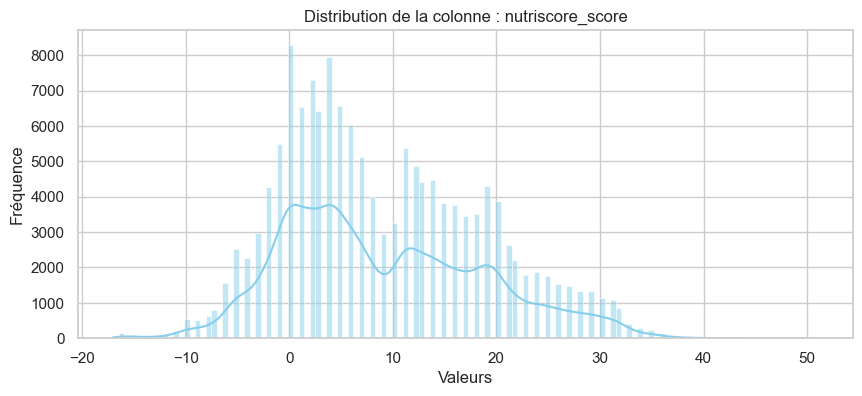

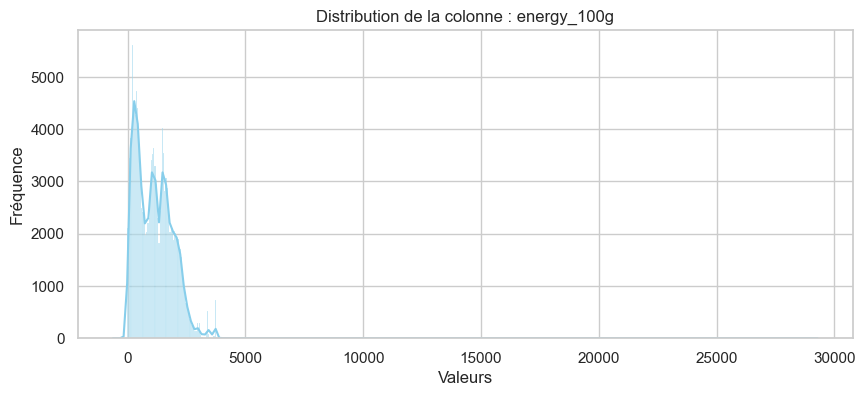

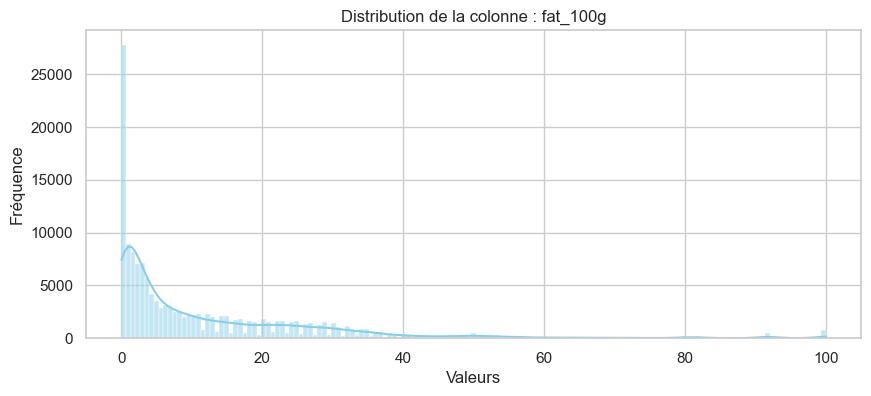

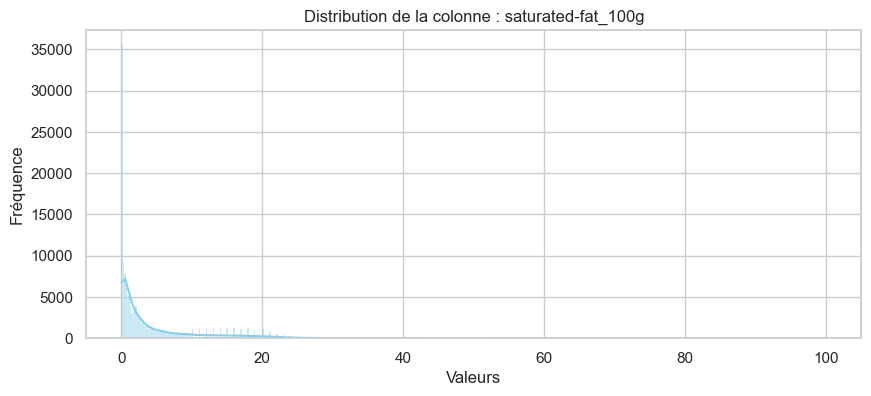

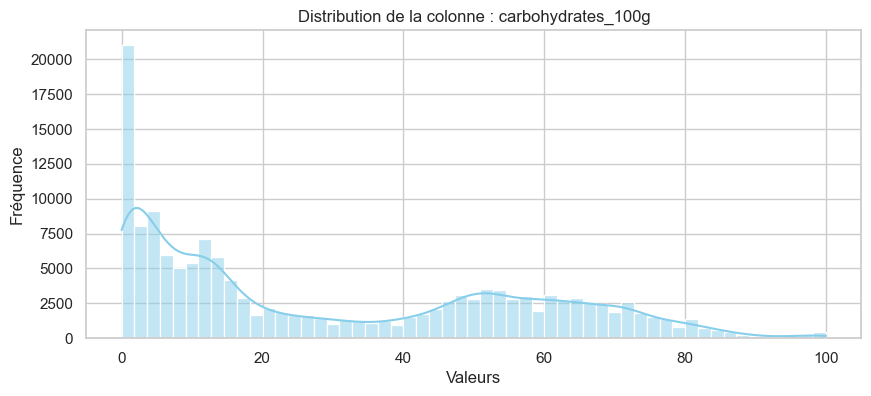

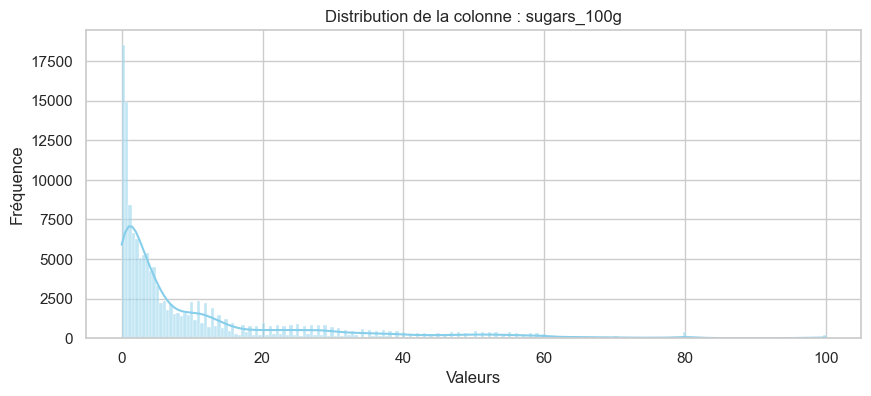

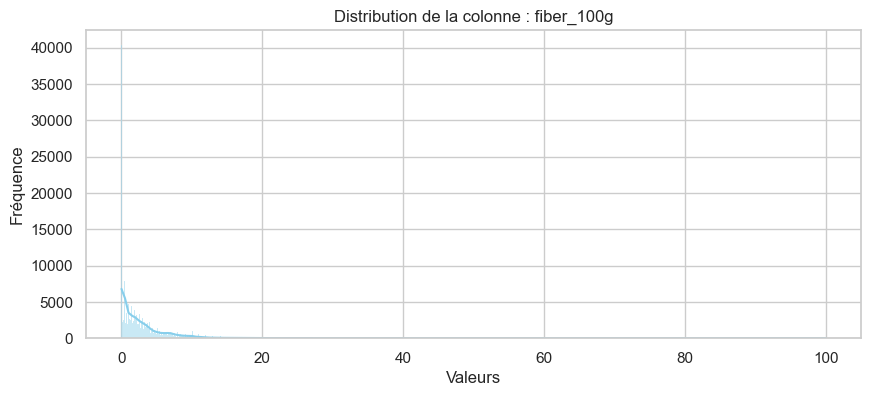

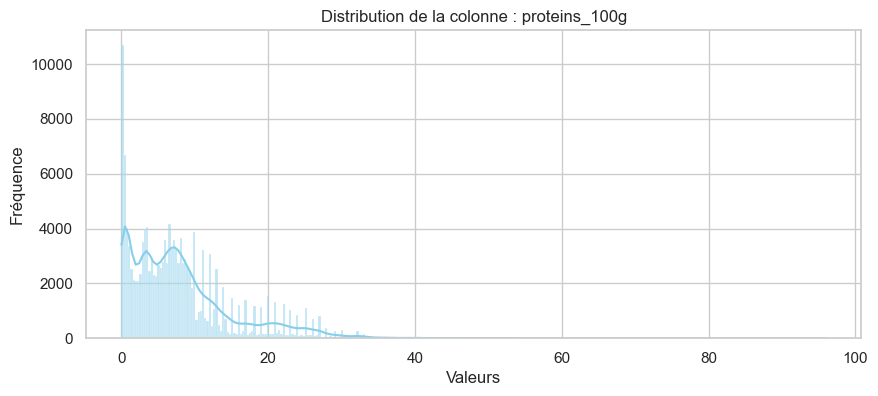

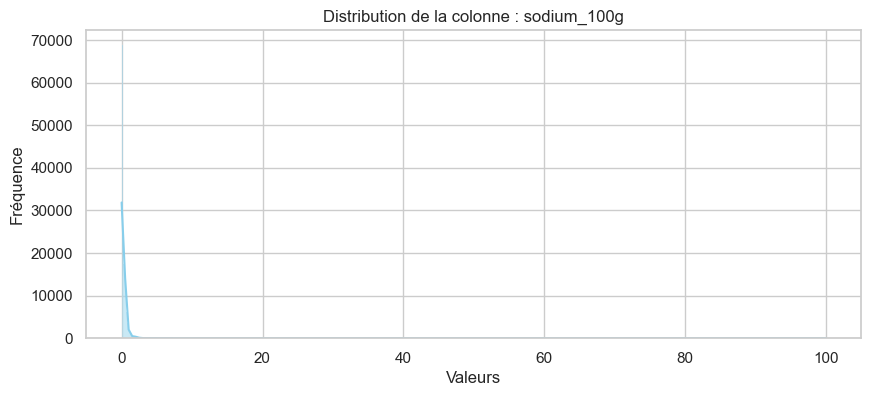

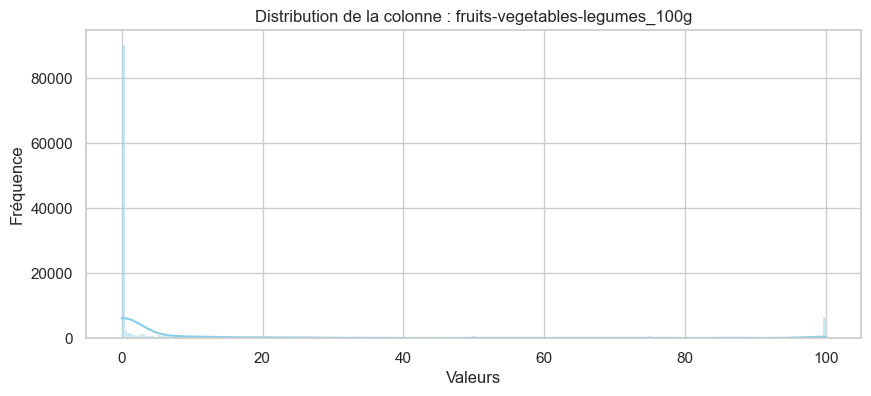

In [6]:
# les differentes valeur de nutriscore_grade 
df = pd.read_csv(fichier_out, sep=';', encoding="utf-8" , on_bad_lines='skip')


# remove all lines with a energy_100g is nan 
df = df.dropna(subset=['energy_100g'])
df = df[df['energy_100g'] <= 37000] # maximum physiquement possible pour 100g de produit (max 37 kJ/g , ce qui correspond à 37000 kJ pour 100g de produit)


# remove all lines with more than 100 for each   "energy_100g","sugars_100g", "saturated-fat_100g", "sodium_100g", "proteins_100g", "fiber_100g", "fruits-vegetables-legumes_100g","fat_100g","carbohydrates_100g"
# parce que c'est pas possible d'avoir plus de 100g pour 100g de produit, on peut supposer que ce sont des erreurs de saisie et les retirer
# and less than 0 because it's not possible to have negative values for these columns, we can assume that they are also data entry errors and remove them
for col in ["sugars_100g", "saturated-fat_100g", "sodium_100g", "proteins_100g", "fiber_100g", "fruits-vegetables-legumes_100g","fat_100g","carbohydrates_100g"]:
    df = df[df[col] <= 100]
    df = df[df[col] >= 0]

print("Distribution de nutriscore_grade:")
print(df['nutriscore_grade'].value_counts())

# faire les stats descriptives pour les colonnes numeriques apres le nettoyage (moyenne, min, max, count)
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns
for col in colonnes_numeriques:
    print(f"Colonne: {col}")
    print(f"  Count (non nulles): {df[col].count()} ({df[col].count() / len(df):.2%})")
    print(f"  Somme: {df[col].sum()}")
    print(f"  Minimum: {df[col].min()}")
    print(f"  Maximum: {df[col].max()}")
    print(f"  Moyenne: {df[col].mean()}")
    # distribution des valeurs pour chaque colonne numerique (histogramme)
    print(f"  Distribution des valeurs (histogramme):")
    print("-" * 40)


import matplotlib.pyplot as plt
import seaborn as sns

# On définit le style des graphiques
sns.set(style="whitegrid")


# Sélection des colonnes numériques
cols_numeriques = df.select_dtypes(include=['float64', 'int64']).columns

# Création d'un distribution plot pour chaque colonne numérique
for col in cols_numeriques:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution de la colonne : {col}')
    plt.xlabel('Valeurs')
    plt.ylabel('Fréquence')
    plt.show()



In [7]:
# save the cleaned dataset to a new csv file

df.to_csv("datasets/nutriscore_donnees_propres_final.csv", index=False, sep=';')

In [ ]:
# csv with all columns with grade and score full*

features = ()
code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
last_modified_by
last_updated_t
last_updated_datetime
product_name
abbreviated_product_name
generic_name
quantity
packaging
packaging_tags
packaging_en
packaging_text
brands
brands_tags
brands_en
categories
categories_tags
categories_en
origins
origins_tags
origins_en
manufacturing_places
manufacturing_places_tags
labels
labels_tags
labels_en
emb_codes
emb_codes_tags
first_packaging_code_geo
cities
cities_tags
purchase_places
stores
countries
countries_tags
countries_en
ingredients_text
ingredients_tags
ingredients_analysis_tags
allergens
allergens_en
traces
traces_tags
traces_en
serving_size
serving_quantity
no_nutrition_data
additives_n
additives
additives_tags
additives_en
nutriscore_score
nutriscore_grade
nova_group
pnns_groups_1
pnns_groups_2
food_groups
food_groups_tags
food_groups_en
states
states_tags
states_en
brand_owner
environmental_score_score
environmental_score_grade
nutrient_levels_tags
product_quantity
owner
data_quality_errors_tags
unique_scans_n
popularity_tags
completeness
last_image_t
last_image_datetime
main_category
main_category_en
image_url
image_small_url
image_ingredients_url
image_ingredients_small_url
image_nutrition_url
image_nutrition_small_url
energy-kj_100g
energy-kcal_100g
energy_100g
energy-from-fat_100g
fat_100g
saturated-fat_100g
butyric-acid_100g
caproic-acid_100g
caprylic-acid_100g
capric-acid_100g
lauric-acid_100g
myristic-acid_100g
palmitic-acid_100g
stearic-acid_100g
arachidic-acid_100g
behenic-acid_100g
lignoceric-acid_100g
cerotic-acid_100g
montanic-acid_100g
melissic-acid_100g
unsaturated-fat_100g
monounsaturated-fat_100g
omega-9-fat_100g
polyunsaturated-fat_100g
omega-3-fat_100g
omega-6-fat_100g
alpha-linolenic-acid_100g
eicosapentaenoic-acid_100g
docosahexaenoic-acid_100g
linoleic-acid_100g
arachidonic-acid_100g
gamma-linolenic-acid_100g
dihomo-gamma-linolenic-acid_100g
oleic-acid_100g
elaidic-acid_100g
gondoic-acid_100g
mead-acid_100g
erucic-acid_100g
nervonic-acid_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
added-sugars_100g
sucrose_100g
glucose_100g
fructose_100g
galactose_100g
lactose_100g
maltose_100g
maltodextrins_100g
psicose_100g
starch_100g
polyols_100g
erythritol_100g
isomalt_100g
maltitol_100g
sorbitol_100g
fiber_100g
soluble-fiber_100g
polydextrose_100g
insoluble-fiber_100g
proteins_100g
casein_100g
serum-proteins_100g
nucleotides_100g
salt_100g
added-salt_100g
sodium_100g
alcohol_100g
vitamin-a_100g
beta-carotene_100g
vitamin-d_100g
vitamin-e_100g
vitamin-k_100g
vitamin-c_100g
vitamin-b1_100g
vitamin-b2_100g
vitamin-pp_100g
vitamin-b6_100g
vitamin-b9_100g
folates_100g
vitamin-b12_100g
biotin_100g
pantothenic-acid_100g
silica_100g
bicarbonate_100g
potassium_100g
chloride_100g
calcium_100g
phosphorus_100g
iron_100g
magnesium_100g
zinc_100g
copper_100g
manganese_100g
fluoride_100g
selenium_100g
chromium_100g
molybdenum_100g
iodine_100g
caffeine_100g
taurine_100g
methylsulfonylmethane_100g
ph_100g
fruits-vegetables-legumes_100g
collagen-meat-protein-ratio_100g
cocoa_100g
chlorophyl_100g
carbon-footprint_100g
glycemic-index_100g
water-hardness_100g
choline_100g
phylloquinone_100g
beta-glucan_100g
inositol_100g
carnitine_100g
sulphate_100g
nitrate_100g
acidity_100g
carbohydrates-total_100g